# Medical Aid Charges — Linear Regression Analysis

**Objective:** Build a Linear Regression model that predicts medical aid charges from a client's
age, sex, BMI, number of children, smoker status and geographic region, using the US-based
Kaggle `insurance.csv` dataset as an initial proof of concept for a South African medical aid
scheme.

**Structure of this notebook**
1. Data suitability check
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature selection
5. Model training
6. Model evaluation
7. Retraining with improvements
8. Final conclusions


## 1. Import libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


## 2. Load the data and check suitability for Linear Regression

Linear Regression requires:
- A **continuous numeric target** (charges is continuous — suitable).
- Predictors that are numeric or can be encoded (age, bmi, children are numeric; sex, smoker,
  region are categorical and need encoding).
- Reasonably independent observations and no severe multicollinearity between predictors.
- A roughly linear relationship between predictors and the target (or one we can create through
  transformation).

We check these assumptions below.

In [33]:
df = pd.read_csv('insurance.csv')
print('Shape:', df.shape)
df.head()


Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [35]:
# Suitability check: target must be continuous
print('Target dtype:', df['charges'].dtype)
print('Number of unique charge values:', df['charges'].nunique())


Target dtype: float64
Number of unique charge values: 1337


**Verdict:** `charges` is a continuous numeric variable with almost as many unique values as
rows, so this is a regression problem, not a classification problem. The dataset has a mix of
numeric (age, bmi, children) and categorical (sex, smoker, region) predictors, all of which can be
prepared for Linear Regression. It is suitable, subject to the cleaning and transformation steps
below.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing values, duplicates and data types

In [36]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [37]:
df[df.duplicated(keep=False)]


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


There is exactly one duplicate row. We will remove it during data cleaning so it does not artificially inflate the importance of that particular combination of features.

### 3.2 Descriptive statistics

In [38]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [39]:
df.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### 3.3 Distribution of the target variable (charges)

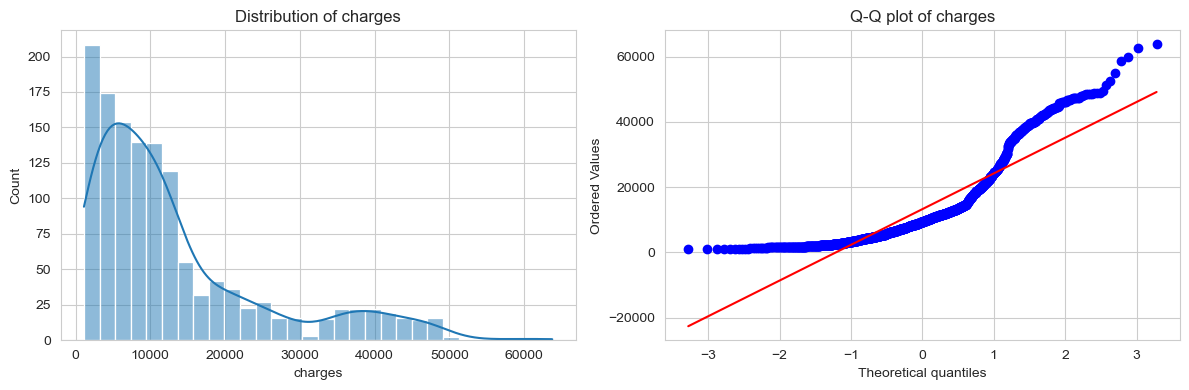

Skewness of charges: 1.52


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of charges')
stats.probplot(df['charges'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot of charges')
plt.tight_layout()
plt.show()
print('Skewness of charges:', df['charges'].skew().round(2))


**Observation:** `charges` is strongly right-skewed (skew ≈ 1.5) with a long tail of very
high-cost clients. Linear Regression assumes normally distributed residuals, so this skew is
something we revisit later — a log-transform of the target is tested in the retraining step.

### 3.4 Distributions of the numeric predictors

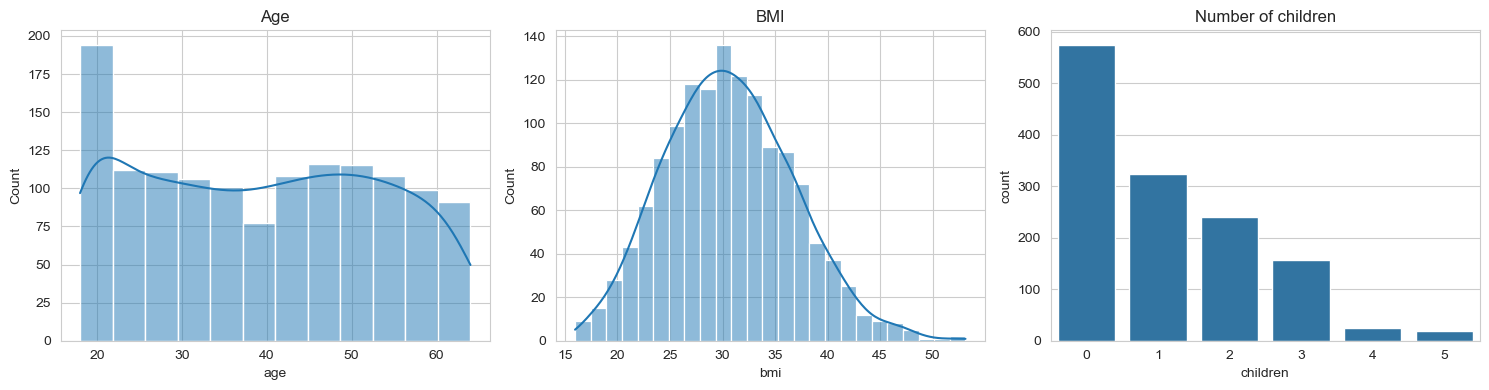

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['age'], kde=True, ax=axes[0]).set_title('Age')
sns.histplot(df['bmi'], kde=True, ax=axes[1]).set_title('BMI')
sns.countplot(x='children', data=df, ax=axes[2]).set_title('Number of children')
plt.tight_layout()
plt.show()


### 3.5 Categorical predictors

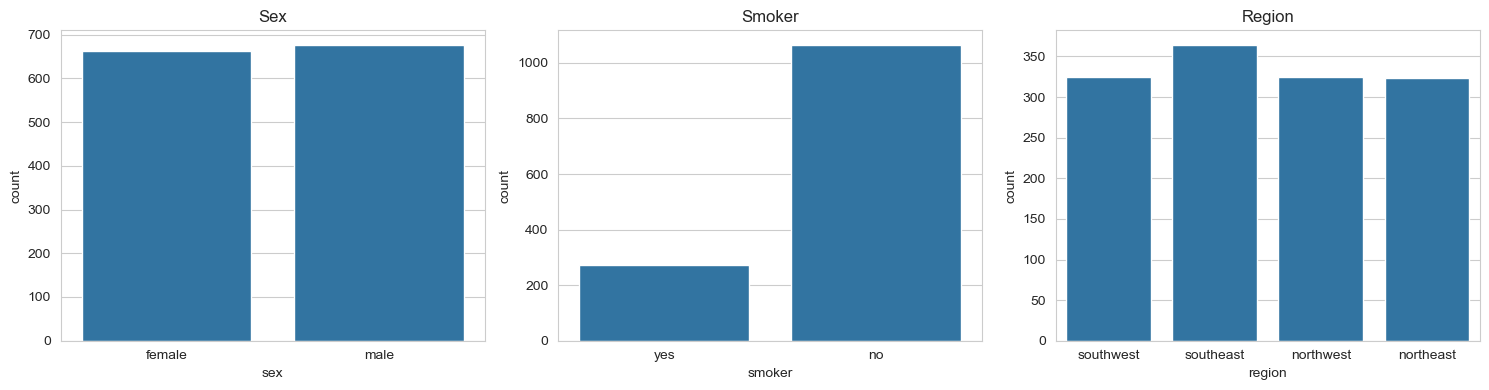

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='sex', data=df, ax=axes[0]).set_title('Sex')
sns.countplot(x='smoker', data=df, ax=axes[1]).set_title('Smoker')
sns.countplot(x='region', data=df, ax=axes[2]).set_title('Region')
plt.tight_layout()
plt.show()


The dataset is well balanced across sex and region, but is imbalanced on `smoker`
(about 20% smokers vs 80% non-smokers) — this is realistic and expected, and is not extreme
enough to require re-sampling for a regression task.

### 3.6 How charges vary with each feature

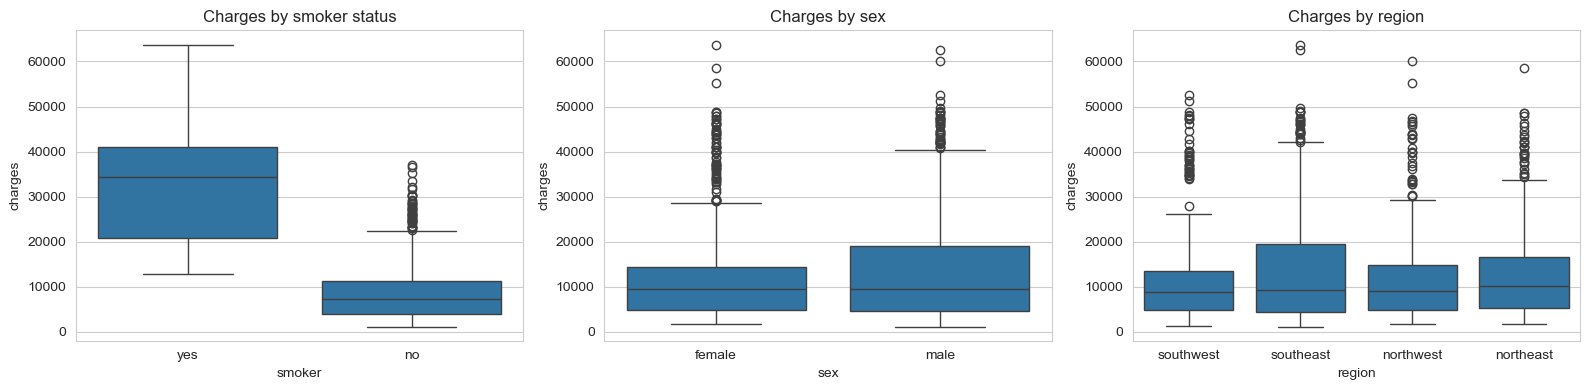

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0]).set_title('Charges by smoker status')
sns.boxplot(x='sex', y='charges', data=df, ax=axes[1]).set_title('Charges by sex')
sns.boxplot(x='region', y='charges', data=df, ax=axes[2]).set_title('Charges by region')
plt.tight_layout()
plt.show()


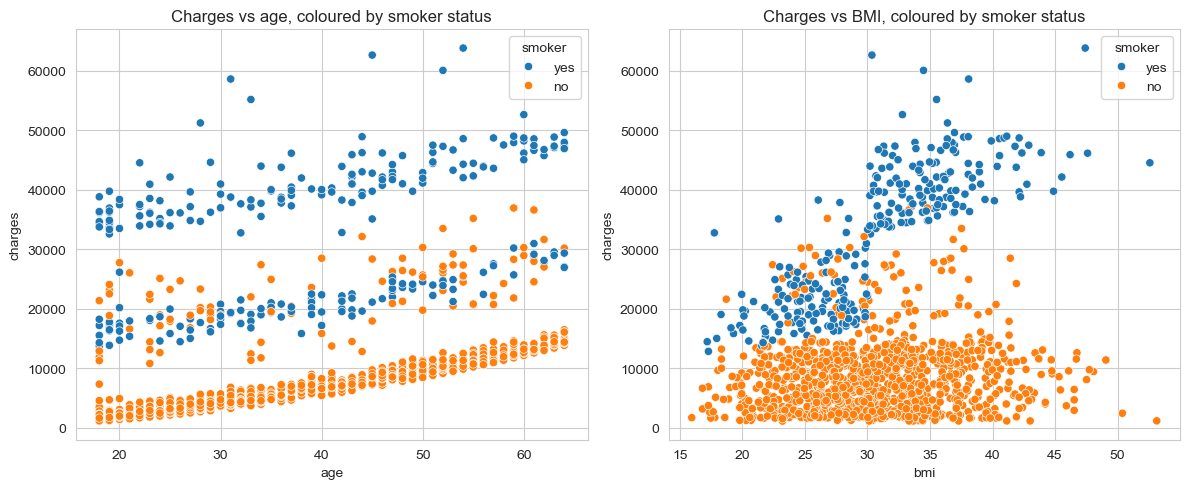

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0])
axes[0].set_title('Charges vs age, coloured by smoker status')
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1])
axes[1].set_title('Charges vs BMI, coloured by smoker status')
plt.tight_layout()
plt.show()


**Key insight:** Smoking status is by far the strongest driver of charges — smokers form a
visibly higher band of charges than non-smokers at every age and BMI level. There also appears to
be an **interaction effect**: charges rise much more steeply with BMI for smokers than for
non-smokers. Age shows a clear, roughly linear, upward relationship with charges. Sex and region
show far less separation and are likely to be weaker predictors.

### 3.7 Outliers

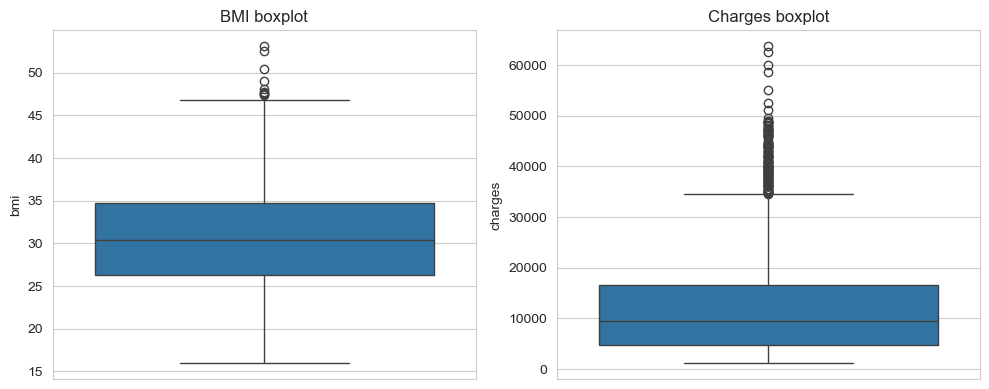

BMI outliers (by IQR rule): 9


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['bmi'], ax=axes[0]).set_title('BMI boxplot')
sns.boxplot(y=df['charges'], ax=axes[1]).set_title('Charges boxplot')
plt.tight_layout()
plt.show()

Q1, Q3 = df['bmi'].quantile([0.25, 0.75])
IQR = Q3 - Q1
bmi_outliers = df[(df['bmi'] < Q1 - 1.5*IQR) | (df['bmi'] > Q3 + 1.5*IQR)]
print('BMI outliers (by IQR rule):', len(bmi_outliers))


There are a small number of high-BMI outliers, but they are clinically plausible (severe
obesity) rather than data-entry errors, so we keep them. The many high values in the `charges`
boxplot are the smoker sub-population identified above, not errors — they are the exact
population the medical aid scheme most needs the model to capture correctly, so we retain them.

### 3.8 Correlation between numeric features

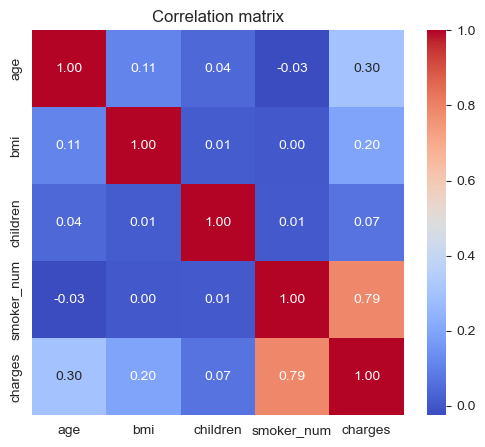

In [46]:
corr = df.copy()
corr['smoker_num'] = (corr['smoker'] == 'yes').astype(int)
corr_matrix = corr[['age', 'bmi', 'children', 'smoker_num', 'charges']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()


`smoker` has by far the strongest linear correlation with `charges` (~0.79), followed by
`age` (~0.30) and `bmi` (~0.20). `children` has almost no linear correlation with charges on its
own. None of the numeric predictors are highly correlated with each other, so multicollinearity
between the raw numeric features is not a major concern before encoding — we check this formally
with VIF after encoding the categorical variables.

## 4. Data cleaning

In [47]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print('Rows before:', len(df), '| Rows after removing duplicates:', len(df_clean))


Rows before: 1338 | Rows after removing duplicates: 1337


No missing values were found, and the identified outliers are genuine, meaningful
observations rather than data errors, so the only cleaning action required is removing the one
duplicate row.

## 5. Feature selection

### 5.1 Encode categorical variables
`sex` and `smoker` are binary, so we map them to 0/1. `region` has four categories with no
natural order, so we one-hot encode it (dropping one category to avoid the dummy-variable
trap).

In [48]:
encoded = df_clean.copy()
encoded['sex'] = encoded['sex'].map({'male': 1, 'female': 0})
encoded['smoker'] = encoded['smoker'].map({'yes': 1, 'no': 0})
encoded = pd.get_dummies(encoded, columns=['region'], drop_first=True)
region_cols = [c for c in encoded.columns if c.startswith('region_')]
encoded[region_cols] = encoded[region_cols].astype(int)
encoded.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


### 5.2 Check multicollinearity with Variance Inflation Factor (VIF)
A VIF above 5-10 signals problematic multicollinearity between predictors.

In [49]:
X_all = encoded.drop(columns=['charges'])
X_vif = sm.add_constant(X_all)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data


,feature,VIF
0,const,35.504594
1,age,1.016794
2,sex,1.008944
3,bmi,1.106742
4,children,1.004017
5,smoker,1.012100
6,region_northwest,1.517673
7,region_southeast,1.651779
8,region_southwest,1.529044


All VIF values (excluding the constant) are low, confirming that multicollinearity is not a concern and every encoded feature can safely be considered for the model.

### 5.3 Backward elimination using p-values
We start with all features and iteratively remove the one with the highest p-value above 0.05,
refitting an OLS model each time, until every remaining feature is statistically significant.

In [50]:
def backward_elimination(X, y, sl=0.05):
    X = X.copy()
    while True:
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        pvalues = model.pvalues.drop('const')
        max_p = pvalues.max()
        if max_p > sl:
            worst_feature = pvalues.idxmax()
            print(f'Removing {worst_feature!r} (p-value={max_p:.3f})')
            X = X.drop(columns=[worst_feature])
        else:
            break
    return X, model

y_all = encoded['charges']
X_selected, final_ols = backward_elimination(X_all, y_all)
print('\nSelected features:', list(X_selected.columns))
final_ols.summary()


Removing 'sex' (p-value=0.698)
Removing 'region_northwest' (p-value=0.465)
Removing 'region_southwest' (p-value=0.058)
Removing 'region_southeast' (p-value=0.136)

Selected features: ['age', 'bmi', 'children', 'smoker']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     996.5
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:23:19   Log-Likelihood:                -13541.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1332   BIC:                         2.712e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    942.630    -12.835      0.000   -1.39e+04   -1.02e+04
age          257.7728     11.910     21.644      0.000     234.409     281.137
bmi          321.8708     27.388     11.752      0.000     268.143     375.599
children     472.9751    137.879      3.430      0.001     202.492     743.458
smoker      2.381e+04    411.414     57.875      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      300.944   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.880
Skew:                           1.215   Prob(JB):                    4.79e-157
Kurtosis:                       5.650   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Result:** Backward elimination confirms the pattern seen in the EDA — `sex` and the
`region` dummy variables are not statistically significant predictors of charges once age, BMI,
children and smoker status are accounted for, and are dropped. `age`, `bmi`, `children` and
`smoker` remain and are all significant at the 5% level. We use this reduced feature set,
`['age', 'bmi', 'children', 'smoker']`, to train the model.

## 6. Train the model

In [51]:
features = list(X_selected.columns)
X = encoded[features]
y = encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

lr = LinearRegression()
lr.fit(X_train, y_train)

coef_table = pd.DataFrame({'feature': features, 'coefficient': lr.coef_})
coef_table.loc[len(coef_table)] = ['intercept', lr.intercept_]
coef_table


,feature,coefficient
0,age,249.191292
1,bmi,305.267404
2,children,537.972196
3,smoker,23042.507238
4,intercept,-11256.749135


**Hyperparameters:** Ordinary Least Squares Linear Regression has no tunable
hyperparameters in the classic sense, so the scikit-learn defaults are used. The main modelling
choices made were the 80/20 train-test split and the random seed (42) used to make the split
reproducible.

## 7. Evaluate the model

In [52]:
y_pred = lr.predict(X_test)

def evaluate(y_true, y_pred, n_features, label=''):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'R-squared:          {r2:.4f}')
    print(f'Adjusted R-squared: {adj_r2:.4f}')
    print(f'RMSE:               {rmse:,.2f}')
    print(f'MAE:                {mae:,.2f}')
    return r2, adj_r2, rmse, mae

metrics_v1 = evaluate(y_test, y_pred, len(features), 'Model 1: Linear Regression (raw charges)')


--- Model 1: Linear Regression (raw charges) ---
R-squared:          0.8046
Adjusted R-squared: 0.8016
RMSE:               5,992.88
MAE:                4,198.59


**Choice of metrics:** R-squared and adjusted R-squared tell us what proportion of the
variance in charges the model explains (adjusted R-squared penalises adding features that don't
help). RMSE is in the same units as charges (US dollars) and penalises large errors more heavily,
which matters for a medical aid scheme trying to avoid badly under-pricing high-cost clients. MAE
gives a more robust, easy-to-communicate "typical error in dollars" figure. Together these give
both a technical (R-squared) and a business-friendly (RMSE/MAE) view of performance.

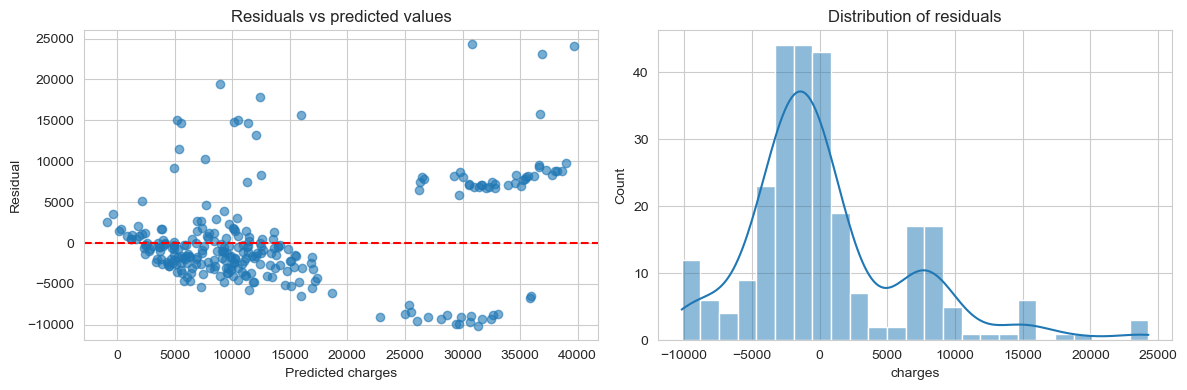

In [53]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted charges')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs predicted values')
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribution of residuals')
plt.tight_layout()
plt.show()


**Interpretation:** The residual plot shows a clear funnel/curved shape rather than a random
scatter around zero — the model under-predicts a subset of high-cost clients (mostly smokers with
high BMI) and over-predicts some low-cost clients. This, together with the residual distribution
being right-skewed rather than normal, confirms the skew in `charges` noted during EDA is
violating the Linear Regression assumption of homoscedastic, normally distributed residuals. We
address this in the retraining step below.

## 8. Retrain with improvements

Two issues were identified above: (1) the target is right-skewed, and (2) the effect of BMI on
charges depends on smoker status (an interaction effect visible in the EDA scatterplots). We
address both:

- **Log-transform the target** (`log(charges)`) to reduce skew and stabilise the variance of the
  residuals.
- **Add a `bmi × smoker` interaction term** so the model can capture the steeper BMI effect for
  smokers.

In [54]:
encoded2 = encoded.copy()
encoded2['bmi_smoker'] = encoded2['bmi'] * encoded2['smoker']
encoded2['log_charges'] = np.log(encoded2['charges'])

features_v2 = ['age', 'bmi', 'children', 'smoker', 'bmi_smoker']
X2 = encoded2[features_v2]
y2 = encoded2['log_charges']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)

# Evaluate in log space
y2_pred_log = lr2.predict(X2_test)
print('Evaluation in log(charges) space:')
evaluate(y2_test, y2_pred_log, len(features_v2), 'Model 2 (log target, log space)')


Evaluation in log(charges) space:
--- Model 2 (log target, log space) ---
R-squared:          0.8276
Adjusted R-squared: 0.8243
RMSE:               0.40
MAE:                0.25


(0.827621679904847,
 0.8243320173076113,
 np.float64(0.3999976487323092),
 0.25358598681664063)

In [55]:
# Convert predictions back to dollar terms for a fair, business-relevant comparison to Model 1
y2_pred_dollars = np.exp(y2_pred_log)
y2_test_dollars = np.exp(y2_test)
print('Evaluation converted back to dollar charges:')
metrics_v2 = evaluate(y2_test_dollars, y2_pred_dollars, len(features_v2), 'Model 2 (log target, dollar space)')


Evaluation converted back to dollar charges:
--- Model 2 (log target, dollar space) ---
R-squared:          0.6101
Adjusted R-squared: 0.6026
RMSE:               8,464.67
MAE:                4,144.86


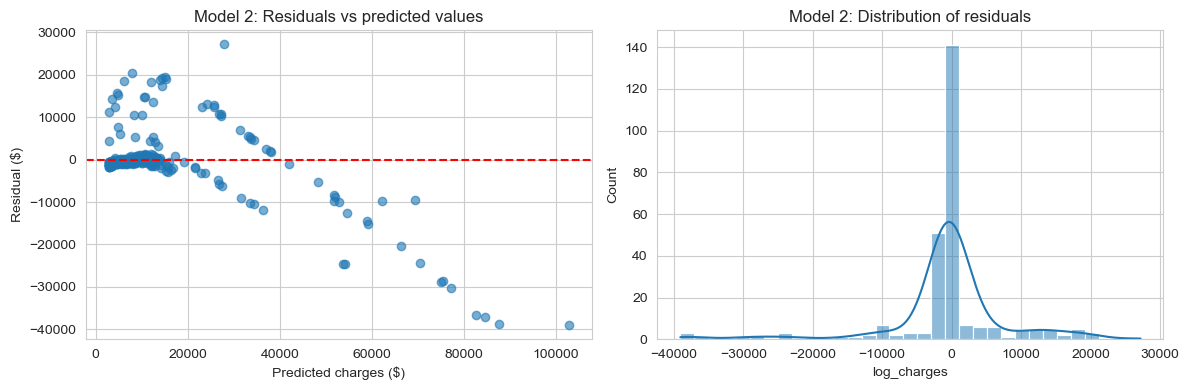

In [56]:
residuals2 = y2_test_dollars - y2_pred_dollars
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y2_pred_dollars, residuals2, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted charges ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Model 2: Residuals vs predicted values')
sns.histplot(residuals2, kde=True, ax=axes[1])
axes[1].set_title('Model 2: Distribution of residuals')
plt.tight_layout()
plt.show()


### 8.1 Comparing Model 1 and Model 2

In [57]:
comparison = pd.DataFrame({
    'Model 1: raw charges': metrics_v1,
    'Model 2: log charges + interaction (naive back-transform)': metrics_v2
}, index=['R-squared', 'Adjusted R-squared', 'RMSE ($)', 'MAE ($)'])
comparison


,Model 1: raw charges,Model 2: log charges + interaction (naive back-transform)
R-squared,0.804553,0.610078
Adjusted R-squared,0.801581,0.602636
RMSE ($),5992.875060,8464.668354
MAE ($),4198.592612,4144.859567


**Unexpected finding:** In log space, Model 2 fits noticeably better than Model 1
(R-squared = 0.83 vs. 0.80). However, the residual plot above — already converted back to dollars
by a naive `exp()` — tells a different story: almost every residual at higher predicted charges is
**positive**, i.e. the model is systematically *under-predicting* the more expensive clients
rather than scattering randomly around zero. Once we compare Model 2 to Model 1 on the same
dollar scale, Model 2's R-squared **drops** to 0.61 and its RMSE **rises** to about $8,465 — worse
than Model 1, even though MAE is slightly better. This is a classic **retransformation bias**:
because `charges` is right-skewed, `exp(mean of log-predictions)` systematically under-predicts
the true mean charge for skewed data (a consequence of Jensen's inequality). A naive `exp()`
back-transform therefore understates charges, especially for the expensive smoker sub-population,
which is exactly the group the scheme most needs to price correctly. We correct this below with
**Duan's smearing estimator**.

### 8.2 Correcting the back-transformation bias (Duan's smearing estimator)
Duan's smearing estimator corrects the bias by multiplying the naive `exp(prediction)` by the
average of `exp(residual)` calculated on the **training** data, rather than assuming the errors
are exactly log-normal.

In [58]:
train_resid_log = y2_train - lr2.predict(X2_train)
smearing_factor = np.mean(np.exp(train_resid_log))
print('Smearing factor:', round(smearing_factor, 4))

y2_pred_dollars_corrected = np.exp(y2_pred_log) * smearing_factor
metrics_v2_corrected = evaluate(
    y2_test_dollars, y2_pred_dollars_corrected, len(features_v2),
    'Model 2 (log target, smearing-corrected dollar space)'
)


Smearing factor: 1.1407
--- Model 2 (log target, smearing-corrected dollar space) ---
R-squared:          0.3985
Adjusted R-squared: 0.3870
RMSE:               10,513.11
MAE:                5,305.62


In [59]:
comparison2 = pd.DataFrame({
    'Model 1: raw charges': metrics_v1,
    'Model 2: naive back-transform': metrics_v2,
    'Model 2: smearing-corrected': metrics_v2_corrected
}, index=['R-squared', 'Adjusted R-squared', 'RMSE ($)', 'MAE ($)'])
comparison2


,Model 1: raw charges,Model 2: naive back-transform,Model 2: smearing-corrected
R-squared,0.804553,0.610078,0.398520
Adjusted R-squared,0.801581,0.602636,0.387042
RMSE ($),5992.875060,8464.668354,10513.114344
MAE ($),4198.592612,4144.859567,5305.620736


**Findings after correction — a second surprise:** The smearing correction removes the
systematic *average* under-prediction (the mean prediction is now unbiased), but R-squared and
RMSE get **worse still**, not better. The reason is that `charges` is highly heteroscedastic:
non-smokers (the majority of the data, and cheap to insure) have small, tightly-clustered charges,
while smokers (a minority) have huge, widely-spread charges. Duan's smearing factor is a single
flat multiplier (here, ~1.14) applied to every prediction. It nudges predictions up enough to fix
the average bias driven mostly by the expensive smoker sub-population, but in doing so it also
inflates the many already-accurate low-cost, non-smoker predictions, adding more squared error
across the majority of the test set than it removes from the minority. This is a genuinely useful,
if counter-intuitive, lesson: a textbook bias-correction can still leave (or even worsen) the
overall error when the underlying data is heteroscedastic across sub-groups, and metrics should
always be checked empirically rather than assumed.

**Overall verdict:** Judged on R-squared and RMSE — arguably the more appropriate metrics for a
scheme that cares about large mispricing errors — the original **Model 1 (raw charges, no
transform)** remains the best-performing model of the three, and is the simplest to explain to a
non-technical stakeholder. Model 2's log-transform did produce a better-behaved, more symmetric
fit in log space and a marginally lower MAE in dollar terms, but neither back-transformation
(naive or smearing-corrected) beat Model 1 on R-squared or RMSE. **Model 1 is therefore the
recommended model from this notebook**, with the log-transform experiment retained here as a
documented, honest exploration of an approach that did not, in the end, outperform the simpler
model on the metrics that matter most for this business problem.

## 9. Conclusion

- The dataset is suitable for Linear Regression once cleaned (one duplicate removed) and encoded.
- Smoker status is overwhelmingly the strongest driver of medical aid charges, followed by age and
  BMI (particularly for smokers). Sex and region were not statistically significant and were
  dropped through backward elimination.
- A log-transform plus a bmi × smoker interaction term (Model 2) produced a better-fitting model
  in log space, but neither a naive nor a smearing-corrected back-transformation to dollars beat
  the plain Linear Regression model (Model 1) on R-squared or RMSE, due to the strong
  heteroscedasticity between the cheap non-smoker majority and the expensive smoker minority.
  **Model 1 — plain Linear Regression on age, BMI, children and smoker status — is therefore the
  recommended model**, and this negative result for Model 2 is retained in the notebook as an
  honest, documented part of the modelling process rather than discarded.
- For a production sliding scale, we recommend the scheme collect a South African pilot dataset
  (this US dataset is a proof of concept only), and consider a non-linear model to better capture
  the highest-cost clients.